In [2]:
import numpy as np
from sklearn import metrics
import pickle

from tools import load, estimate_derivative, pseudoderivative, normalize, whiten
from matplotlib import font_manager as fm, rcParams


In [3]:
n_hd = 10000
n_out = 3

n_train = 450
filename = '1_600_20'
file_save = 'gs_single'

In [4]:
sensor_data, sequence, times_sec, sequence_sec = load(filename, reduced=True)
d_sensor_data = np.apply_along_axis(estimate_derivative, axis=0, arr=sensor_data)
sensor_data = np.hstack((sensor_data, d_sensor_data))

In [7]:
col_min = np.min(sensor_data, axis=0, keepdims=True)
col_max = np.max(sensor_data, axis=0, keepdims=True)
denom = col_max - col_min
# denom[denom == 0] = 1.
min_max = (sensor_data - col_min) / denom
normalize = normalize(sensor_data)
whiten = whiten(normalize)

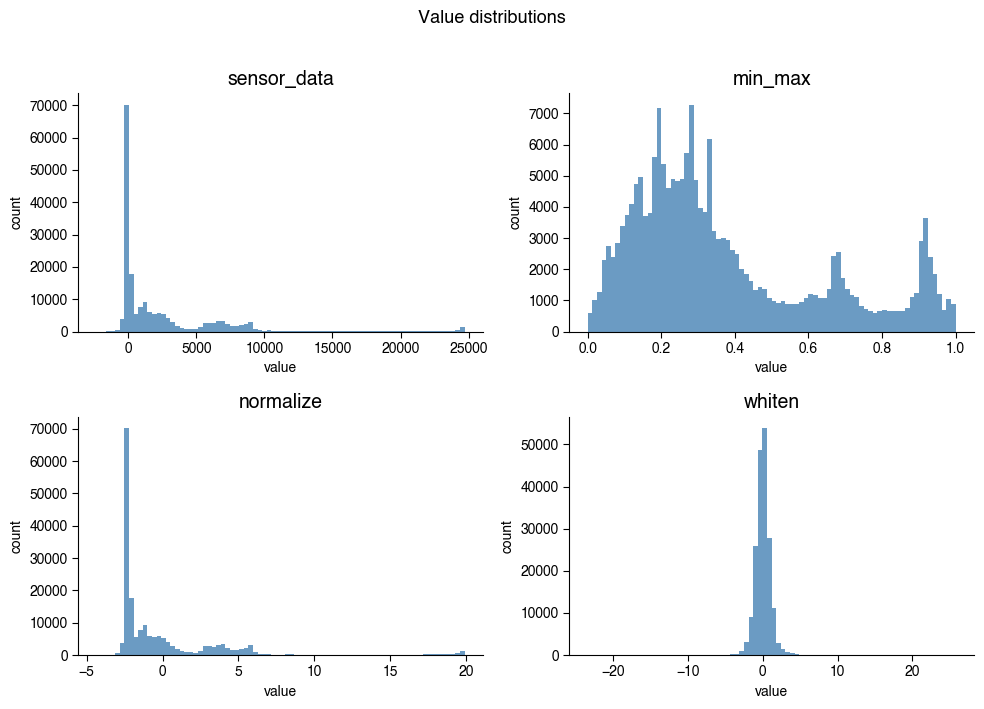

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

datasets = {
    'sensor_data': sensor_data,
    'min_max': min_max,
    'normalize': normalize,
    'whiten': whiten,
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

for ax, (name, data) in zip(axes, datasets.items()):
    ax.hist(data.ravel(), bins=80, color='steelblue', alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('value')
    ax.set_ylabel('count')

plt.suptitle('Value distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

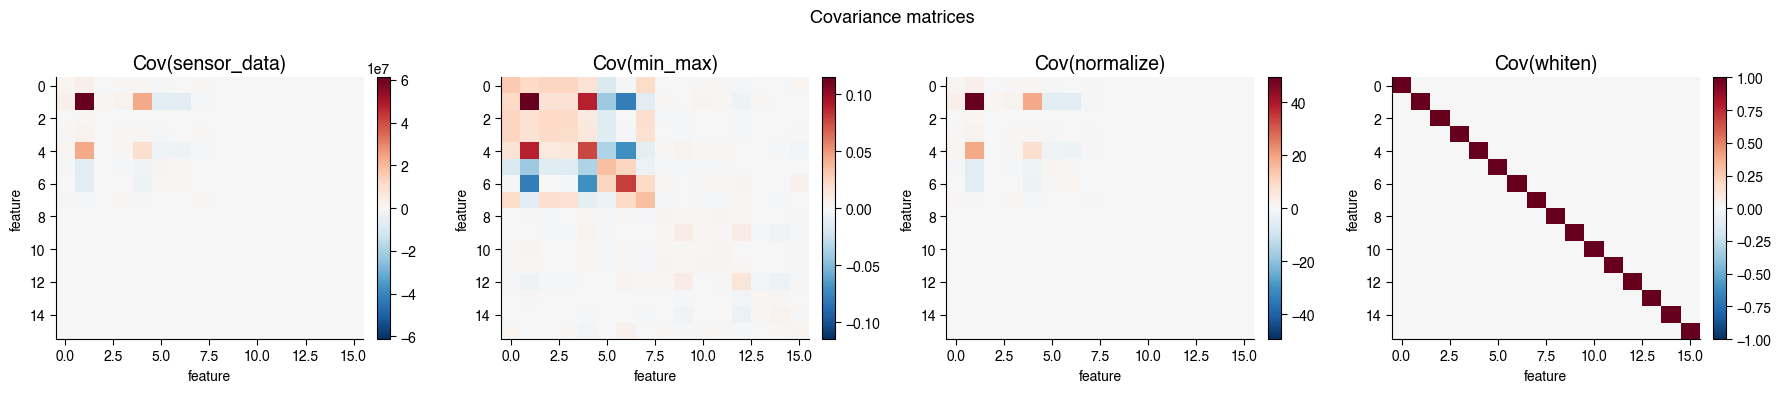

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, data) in zip(axes, datasets.items()):
    cov = np.cov(data.T)
    vmax = np.abs(cov).max()
    im = ax.imshow(cov, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(f'Cov({name})')
    ax.set_xlabel('feature')
    ax.set_ylabel('feature')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Covariance matrices', fontsize=13)
plt.tight_layout()
plt.show()